/tmp/ipykernel_3694358/4204731306.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=28)  # Increased font size


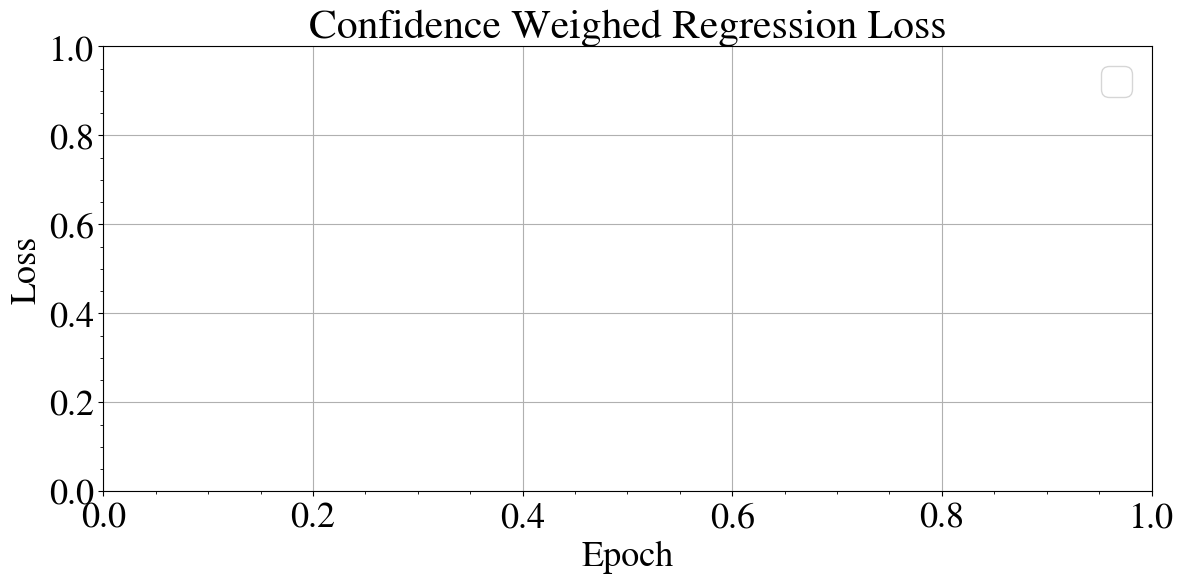

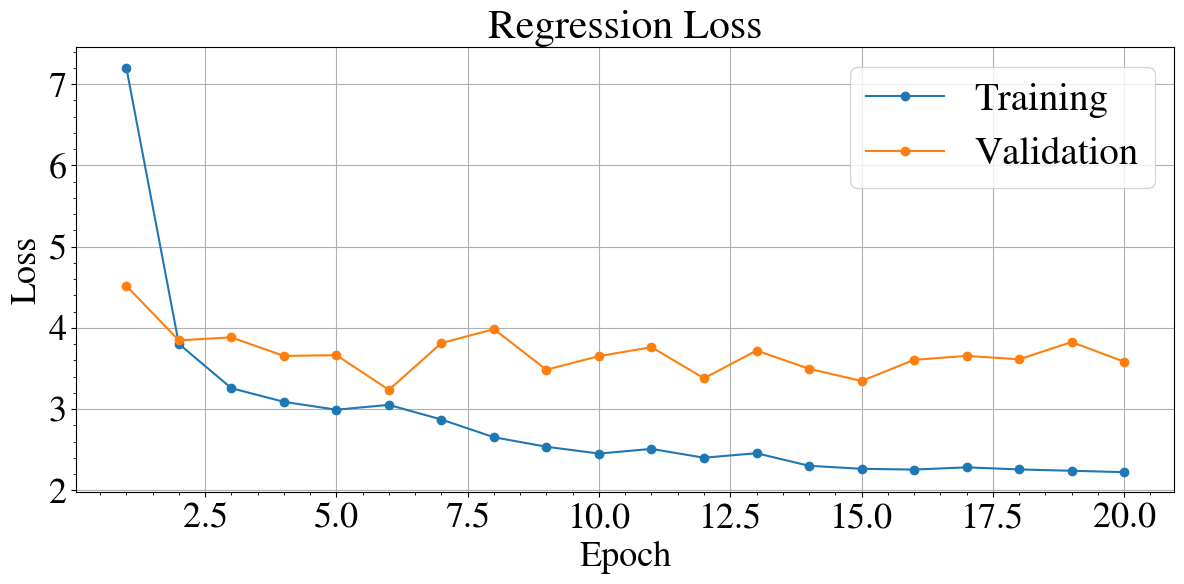

In [ ]:
## CELL TO PLOT PER EPOCH AVERAGED VALUES

import pandas as pd
import matplotlib.pyplot as plt
import json
import os

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "STIXGeneral",
})


def plot_training_curves(log_path, columns_to_plot, title=None):
    """
    Plots training curves for specified columns, automatically labeling them based on
    the column names in the log file. Skips plotting columns that don't exist.
    """
    try:
        with open(log_path, 'r') as f:
            log_lines = [json.loads(line) for line in f if line.strip()]

        df = pd.DataFrame(log_lines)

        # Filter valid epochs
        df = df[df['epoch'].notnull()]

        plt.figure(figsize=(12, 6))

        # Plot each specified column, skipping if it doesn't exist
        for col, label in columns_to_plot.items():
            if col in df.columns:
                plt.plot(df['epoch'], df[col], marker='o', label=label)
            else:
                print(f"Warning: Column '{col}' not found in log file. Skipping.")

        plt.xlabel('Epoch', fontsize=26)  # Increased font size
        plt.ylabel('Loss', fontsize=26)  # Increased font size
        if title is not None:
            plt.title(title, fontsize=30)
        else:
            plt.title('Training Curves', fontsize=25)  # Increased font size
        plt.legend(fontsize=28)  # Increased font size
        plt.xticks(fontsize=26)  # Increased tick label font size
        plt.yticks(fontsize=26)  # Increased tick label font size
        # plt.ylim(bottom=0)
        plt.grid(True)
        # plt.grid(True, which='minor', axis='both', alpha=0.5)
        plt.minorticks_on()
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"Error: Log file not found at {log_path}")
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {log_path}. Check file format.")
    except KeyError as e:
        print(f"Error: Required key not found in log file: {e}")

# Example usage: edit base_path
base_path="/home/bjangley/VPR/mast3r-v2/checkpoints_v1/campus_ciampino2_lr5e5_3e6_reg"
log_path = f"{base_path}/log.txt"  # Replace with your log file path

# Now columns_to_plot is a dictionary where keys are column names and values are labels
columns_to_plot = {
    "train_conf_loss_1": "Training",
    "VBRPairsDataset_conf_loss_1_avg": "Validation"
}
plot_training_curves(log_path, columns_to_plot, title="Confidence Weighed Regression Loss")

columns_to_plot = {
    "train_Regr3D_pts3d_1": "Training",
    "VBRPairsDataset_Regr3D_pts3d_1_avg": "Validation"
}
plot_training_curves(log_path, columns_to_plot, title="Regression Loss")

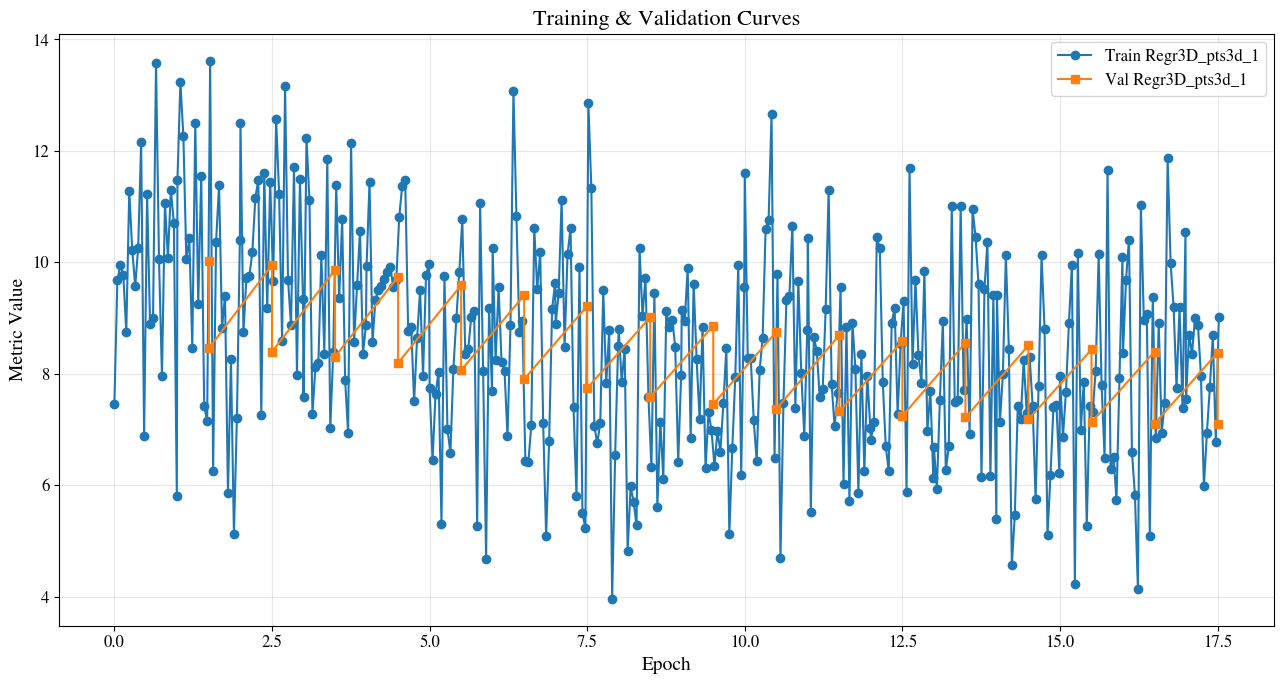

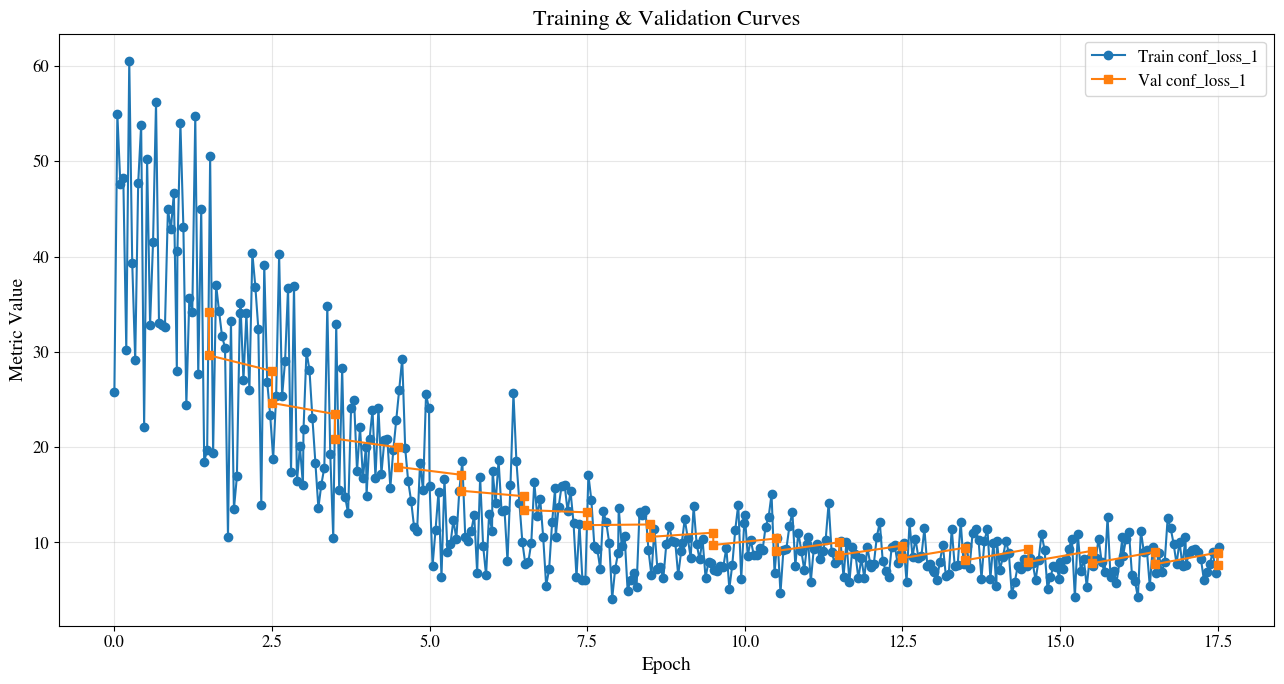

In [ ]:
## Further visualisation

import pandas as pd
import matplotlib.pyplot as plt
import json

# Paths to your iteration logs
path1 = f"{base_path}/log_iter_train.txt"
path2 = f"{base_path}/log_iter_test.txt"

def load_log(path):
    with open(path) as f:
        return pd.DataFrame([json.loads(line) for line in f if line.strip()])

def plot_columns_from_logs(
    train_log_path, 
    val_log_path, 
    columns,  # list of column names to search/plot
    x_col='epoch'  # or 'iter', 'step', etc. as appropriate
):
    df_train = load_log(train_log_path)
    df_val = load_log(val_log_path)

    # Choose x_col intelligently if not provided
    if x_col not in df_train.columns or x_col not in df_val.columns:
        x_col = df_train.columns[0]

    plt.figure(figsize=(13, 7))
    for col in columns:
        found = False
        if col in df_train.columns:
            plt.plot(df_train[x_col], df_train[col], label=f"Train {col}", marker='o')
            found = True
        if col in df_val.columns:
            plt.plot(df_val[x_col], df_val[col], label=f"Val {col}", marker='s')
            found = True
        if not found:
            print(f"Warning: '{col}' not found in either log file.")
    plt.xlabel(x_col.title())
    plt.ylabel("Metric Value")
    # plt.ylim([0,10])
    plt.title("Training & Validation Curves")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_columns_from_logs(path1, path2, ["Regr3D_pts3d_1"])
plot_columns_from_logs(path1, path2, ["conf_loss_1"])
